### Loading Data and Libraries

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/pricing_analyst_cleaned.csv")
FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")
TABLE_PATH = Path("../outputs/tables/summary_table.csv") 

df_analysis = pd.read_csv(DATA_PATH)
summary_table = pd.read_csv(TABLE_PATH)

date_columns = ["offerdate", "purchase_date"]
for col in date_columns:
    df_analysis[col] = pd.to_datetime(df_analysis[col], errors="coerce")

print(df_analysis.shape)
df_analysis.info()
display(df_analysis.head())

(8865, 24)
<class 'pandas.DataFrame'>
RangeIndex: 8865 entries, 0 to 8864
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   offerdate                      8865 non-null   datetime64[us]
 1   sold_premium                   1991 non-null   float64       
 2   offered_premium                8865 non-null   float64       
 3   purchase_price                 8864 non-null   float64       
 4   purchase_date                  8865 non-null   datetime64[us]
 5   item_age                       8862 non-null   float64       
 6   pricing_point                  8865 non-null   str           
 7   predictedconversionrate        8865 non-null   float64       
 8   plan_flag                      8865 non-null   int64         
 9   plan_count                     8824 non-null   float64       
 10  plansactive_lastyear_count     8824 non-null   float64       
 11  planscancelled_la

,offerdate,sold_premium,offered_premium,purchase_price,purchase_date,item_age,pricing_point,predictedconversionrate,plan_flag,plan_count,...,price_diff,ismodel,sale_flag,base_rate,manufacturerbrandname_enc,itemcategoryname_enc,itemsupercategorycode_enc,invalid_price_flag,price_diff_check,price_diff_matches
0,2023-03-17,NaN,32.64,89.99,2023-03-16,1.0,@22%,0.15,0,0.0,...,-0.058824,yes,0,34.68,56,35,14,False,-1.981176,False
1,2023-03-01,69.72,69.72,329.00,2022-12-24,67.0,@22%,0.81,1,5.0,...,-0.023529,yes,1,71.40,123,34,3,False,-1.656471,False
2,2023-04-12,NaN,48.24,249.00,2023-04-05,7.0,@23%,0.08,0,0.0,...,0.210843,yes,0,39.84,7,16,12,False,8.189157,False
3,2023-03-09,NaN,91.92,746.42,2021-03-09,730.0,@23%,0.32,0,0.0,...,0.298305,yes,0,70.80,107,36,4,False,20.821695,False
4,2023-03-18,NaN,89.64,493.98,2023-03-18,0.0,@22%,0.25,1,1.0,...,0.299130,yes,0,69.00,57,36,4,False,20.340870,False


## Price Elasticity

In [12]:
# summary_table = summary_table.set_index("pricing_point")
conversion_asis = summary_table.loc["ASIS FEE", "conversion_rate"]
premium_asis = summary_table.loc["ASIS FEE", "avg_offered_premium"]

def calculate_elasticity(strategy_name, summary_table, conversion_asis, premium_asis):
    conversion_point = summary_table.loc[strategy_name, "conversion_rate"]
    premium_point = summary_table.loc[strategy_name, "avg_offered_premium"]

    pct_change_conversion = (conversion_point - conversion_asis) / conversion_asis
    pct_change_premium = (premium_point - premium_asis) / premium_asis

    elasticity = pct_change_conversion / pct_change_premium
    return elasticity, pct_change_conversion, pct_change_premium

elasticity_22, pct_conv_22, pct_prem_22 = calculate_elasticity("@22%", summary_table, conversion_asis, premium_asis)
elasticity_23, pct_conv_23, pct_prem_23 = calculate_elasticity("@23%", summary_table, conversion_asis, premium_asis)

elasticity_results = pd.DataFrame({
    "strategy": ["@22%", "@23%"],
    "pct_change_conversion": [pct_conv_22, pct_conv_23],
    "pct_change_premium": [pct_prem_22, pct_prem_23],
    "elasticity": [elasticity_22, elasticity_23]
})

display(elasticity_results)

,strategy,pct_change_conversion,pct_change_premium,elasticity
0,@22%,-0.055511,0.127394,-0.435743
1,@23%,-0.028457,0.061318,-0.464082


In [13]:
def within_group_elasticity(df_analysis, strategy_name, low_bin_label, high_bin_label):
    subset = df_analysis[df_analysis["pricing_point"] == strategy_name].copy()

    subset["price_bucket"] = pd.cut(
        subset["price_diff"],
        bins=[-1, -0.05, 0.05, 1],
        labels=["low", "mid", "high"]
    )

    bucket_stats = (
        subset
        .groupby("price_bucket", observed=True)
        .agg(
            avg_premium=("offered_premium", "mean"),
            conversion=("sale_flag", "mean"),
            n=("sale_flag", "size")
        )
    )

    conversion_low = bucket_stats.loc[low_bin_label, "conversion"]
    conversion_high = bucket_stats.loc[high_bin_label, "conversion"]
    premium_low = bucket_stats.loc[low_bin_label, "avg_premium"]
    premium_high = bucket_stats.loc[high_bin_label, "avg_premium"]

    pct_change_conversion = (conversion_high - conversion_low) / conversion_low
    pct_change_premium = (premium_high - premium_low) / premium_low
    elasticity_within = pct_change_conversion / pct_change_premium

    return bucket_stats, elasticity_within

bucket_stats_22, elasticity_within_22 = within_group_elasticity(df_analysis, "@22%", "low", "high")
bucket_stats_23, elasticity_within_23 = within_group_elasticity(df_analysis, "@23%", "low", "high")

print("@22% price buckets:")
display(bucket_stats_22)
print(f"@22% within-group elasticity: {elasticity_within_22:.3f}\n")

print("@23% price buckets:")
display(bucket_stats_23)
print(f"@23% within-group elasticity: {elasticity_within_23:.3f}")

@22% price buckets:


,avg_premium,conversion,n
price_bucket,,,
low,42.841879,0.185682,447
mid,53.539821,0.211310,672
high,57.585578,0.227889,2804


@22% within-group elasticity: 0.660

@23% price buckets:


,avg_premium,conversion,n
price_bucket,,,
low,41.818345,0.224138,870
mid,50.783547,0.204617,953
high,56.954072,0.238024,2004


@23% within-group elasticity: 0.171


In [15]:
elasticity_summary = pd.DataFrame({
    "comparison_type": ["Between groups", "Between groups", "Within group", "Within group"],
    "strategy": ["@22% vs ASIS", "@23% vs ASIS", "@22% (low vs high price)", "@23% (low vs high price)"],
    "elasticity": [elasticity_22, elasticity_23, elasticity_within_22, elasticity_within_23]
})

display(elasticity_summary)
elasticity_summary.to_csv("../outputs/tables/task_c_elasticity.csv", index=False)

,comparison_type,strategy,elasticity
0,Between groups,@22% vs ASIS,-0.435743
1,Between groups,@23% vs ASIS,-0.464082
2,Within group,@22% (low vs high price),0.660495
3,Within group,@23% (low vs high price),0.171169


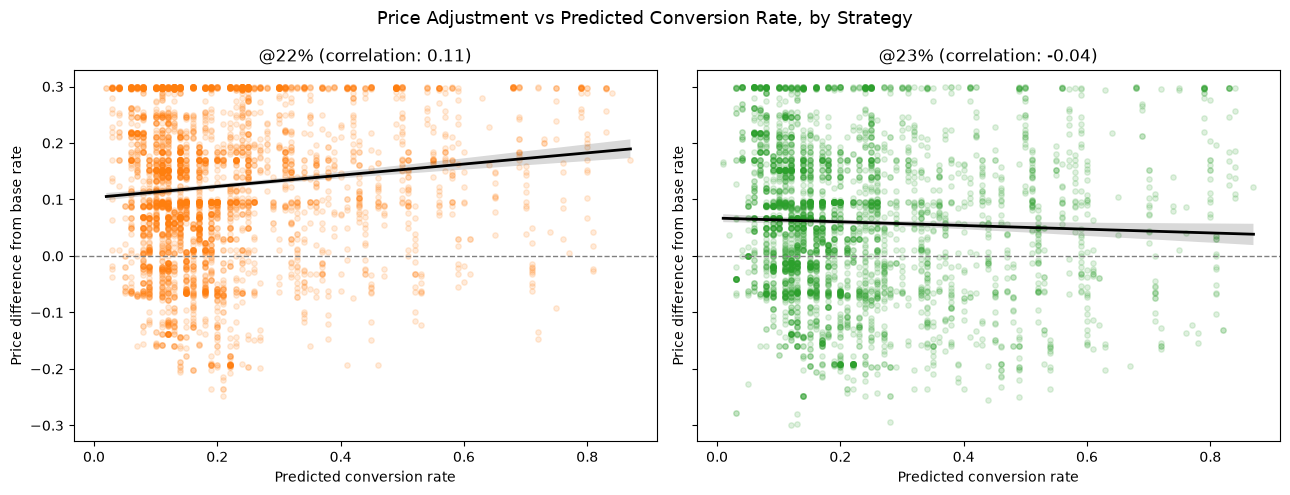

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plot_data = df_analysis[df_analysis["pricing_point"].isin(["@22%", "@23%"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, sharex=True)

for ax, strategy, color in zip(axes, ["@22%", "@23%"], ["tab:orange", "tab:green"]):
    subset = plot_data[plot_data["pricing_point"] == strategy]

    sns.regplot(
        data=subset,
        x="predictedconversionrate",
        y="price_diff",
        scatter_kws={"alpha": 0.15, "s": 15, "color": color},
        line_kws={"color": "black", "linewidth": 2},
        ax=ax
    )

    corr = subset["price_diff"].corr(subset["predictedconversionrate"])
    ax.set_title(f"{strategy} (correlation: {corr:.2f})")
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted conversion rate")
    ax.set_ylabel("Price difference from base rate")

fig.suptitle("Price Adjustment vs Predicted Conversion Rate, by Strategy", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_diff_vs_predicted_conversion.png", dpi=200, bbox_inches="tight")
plt.show()

### Explaining the @23% elasticity

In [17]:
candidate_vars = [
    "plan_flag",
    "item_category_name_enc",
    "claims_count",
    "item_age",
    "plan_count"
]

subset_23 = df_analysis[df_analysis["pricing_point"] == "@23%"].copy()

for col in candidate_vars:
    if col in subset_23.columns:
        corr = subset_23["price_diff"].corr(pd.to_numeric(subset_23[col], errors="coerce"))
        print(f"price_diff vs {col}: correlation = {corr:.3f}")

price_diff vs plan_flag: correlation = 0.025
price_diff vs claims_count: correlation = 0.032
price_diff vs item_age: correlation = 0.130
price_diff vs plan_count: correlation = 0.039


In [18]:
for col in ["plan_flag", "item_category_name_enc"]:
    if col in subset_23.columns:
        print(f"\n--- {col} ---")
        display(
            subset_23
            .groupby(col)
            .agg(
                avg_price_diff=("price_diff", "mean"),
                conversion=("sale_flag", "mean"),
                n=("sale_flag", "size")
            )
        )


--- plan_flag ---


,avg_price_diff,conversion,n
plan_flag,,,
0,0.058014,0.169817,3068
1,0.066441,0.455863,759


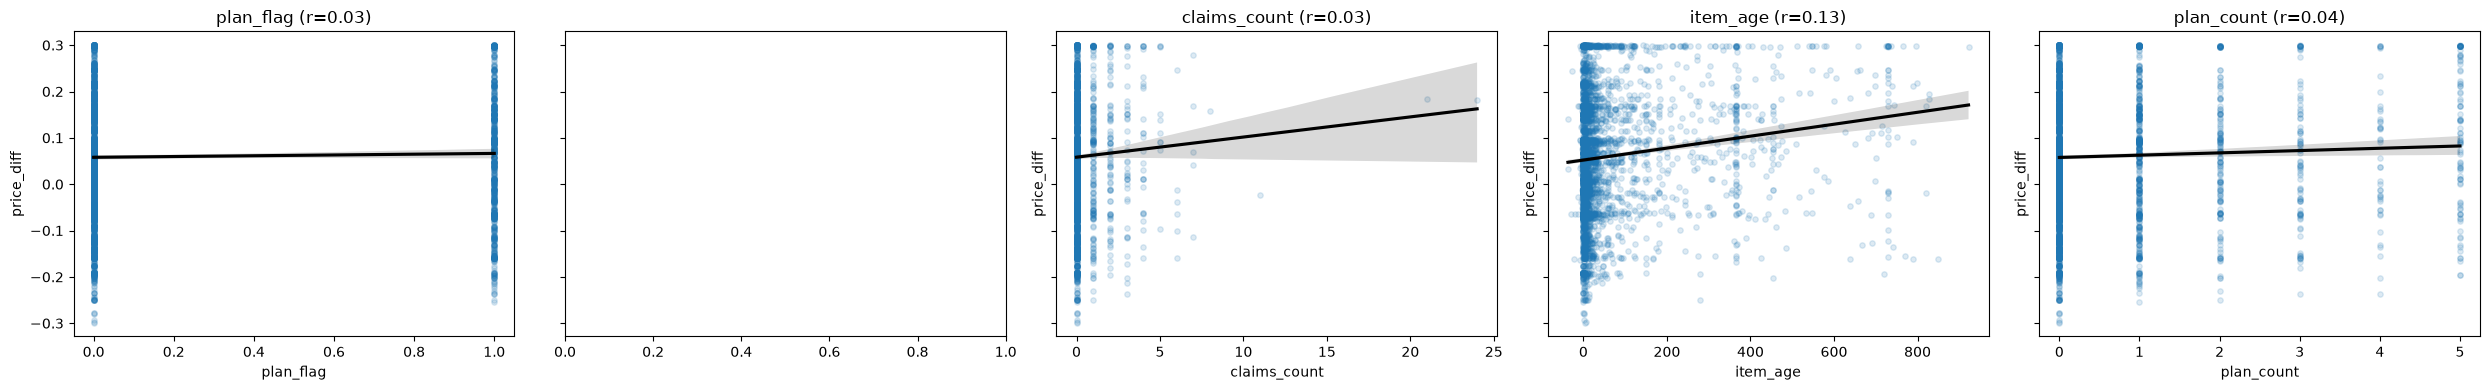

In [19]:
fig, axes = plt.subplots(1, len(candidate_vars), figsize=(5 * len(candidate_vars), 4), sharey=True)

for ax, col in zip(axes, candidate_vars):
    if col in subset_23.columns:
        sns.regplot(
            data=subset_23,
            x=col,
            y="price_diff",
            scatter_kws={"alpha": 0.15, "s": 15},
            line_kws={"color": "black"},
            ax=ax
        )
        corr = subset_23["price_diff"].corr(pd.to_numeric(subset_23[col], errors="coerce"))
        ax.set_title(f"{col} (r={corr:.2f})")

plt.tight_layout()
plt.savefig("../outputs/figures/price_diff_vs_other_vars_23.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
bucket_composition = (
    subset_23
    .assign(
        price_bucket=pd.cut(
            subset_23["price_diff"],
            bins=[-1, -0.05, 0.05, 1],
            labels=["low", "mid", "high"]
        )
    )
    .groupby("price_bucket", observed=True)["plan_flag"]
    .mean()
)

display(bucket_composition)

price_bucket
low     0.220690
mid     0.154250
high    0.209581
Name: plan_flag, dtype: float64